# RoPE и KV-cache в современных LLM

Демонстрация двух идей из лекции:

1. **Почему абсолютные positional embeddings неудобны**
2. **Почему KV-cache резко ускоряет autoregressive decoding**


In [11]:
import math
import time
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4)
np.set_printoptions(precision=3, suppress=True)

## Напоминание про один Transformer block:

$
x \rightarrow \text{Attention} \rightarrow \text{Residual} \rightarrow \text{Norm} \rightarrow \text{MLP} \rightarrow \text{Residual}
$


## Absolute positional embeddings vs RoPE:

Возьмём **одинаковые токены по содержанию** и будем различать их **только позицией**:
- для **absolute positional embeddings** каждый токен получает просто свой абсолютный positional vector;
- для **RoPE** мы будем вращать признаки в зависимости от позиции.

In [2]:
# Вспомогательные функции для блока про позиции

def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)

def build_sinusoidal_table(seq_len, dim, base=10000.0):
    assert dim % 2 == 0
    positions = np.arange(seq_len)[:, None]
    i = np.arange(dim // 2)[None, :]
    freqs = 1.0 / (base ** (2 * i / dim))
    angles = positions * freqs
    table = np.zeros((seq_len, dim))
    table[:, 0::2] = np.sin(angles)
    table[:, 1::2] = np.cos(angles)
    return table

def rotate_half(x):
    # x: (..., d), d must be even
    x1 = x[..., 0::2]
    x2 = x[..., 1::2]
    out = np.empty_like(x)
    out[..., 0::2] = -x2
    out[..., 1::2] = x1
    return out

def apply_rope_batch(x, positions, base=10000.0):
    '''
    x: [T, d]
    positions: [T]
    '''
    T, d = x.shape
    assert d % 2 == 0
    i = np.arange(d // 2)
    freqs = 1.0 / (base ** (2 * i / d))
    angles = positions[:, None] * freqs[None, :]
    cos = np.empty((T, d))
    sin = np.empty((T, d))
    cos[:, 0::2] = np.cos(angles)
    cos[:, 1::2] = np.cos(angles)
    sin[:, 0::2] = np.sin(angles)
    sin[:, 1::2] = np.sin(angles)
    return x * cos + rotate_half(x) * sin

def attention_scores(q, K):
    d = q.shape[-1]
    return (K @ q) / math.sqrt(d)

def attention_map(Q, K):
    d = Q.shape[-1]
    return softmax((Q @ K.T) / math.sqrt(d), axis=-1)

## Демонстрация 1: одинаковые токены, различается только позиция

Здесь у всех токенов один и тот же content vector.  
Различие между позициями вносит только positional mechanism.

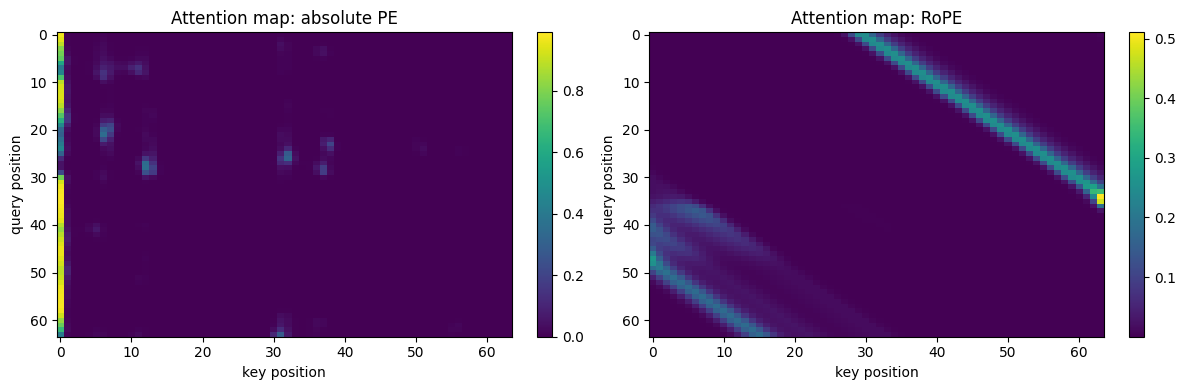

In [3]:
# Параметры
rng = np.random.default_rng(42)
T = 64     # длина последовательности
d = 32     # размерность

# Один и тот же "контент" во всех позициях
base_token = rng.normal(size=(d,))
X_content = np.tile(base_token[None, :], (T, 1))

# Случайные матрицы проекций
Wq = rng.normal(scale=0.6, size=(d, d))
Wk = rng.normal(scale=0.6, size=(d, d))

# ----- Absolute positional embeddings -----
P_abs = build_sinusoidal_table(T, d)   # можно и learned, но sinusoidal стабильнее для демки
X_abs = X_content + P_abs
Q_abs = X_abs @ Wq
K_abs = X_abs @ Wk
A_abs = attention_map(Q_abs, K_abs)

# ----- RoPE -----
Q_base = X_content @ Wq
K_base = X_content @ Wk
positions = np.arange(T)
Q_rope = apply_rope_batch(Q_base, positions)
K_rope = apply_rope_batch(K_base, positions)
A_rope = attention_map(Q_rope, K_rope)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im0 = axes[0].imshow(A_abs, aspect="auto")
axes[0].set_title("Attention map: absolute PE")
axes[0].set_xlabel("key position")
axes[0].set_ylabel("query position")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(A_rope, aspect="auto")
axes[1].set_title("Attention map: RoPE")
axes[1].set_xlabel("key position")
axes[1].set_ylabel("query position")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

## shift-тест


Сравним две ситуации:
- исходная последовательность;
- та же последовательность, но все позиции сдвинуты на `shift`.

Дальше посмотрим, насколько меняется score как функция **относительного расстояния**:
* Для **RoPE** сдвиг всех позиций должен вести себя более естественно,  
потому что модель кодирует относительные сдвиги.  
* Для **absolute PE** абсолютные индексы сами по себе уже “зашиты” в представление.

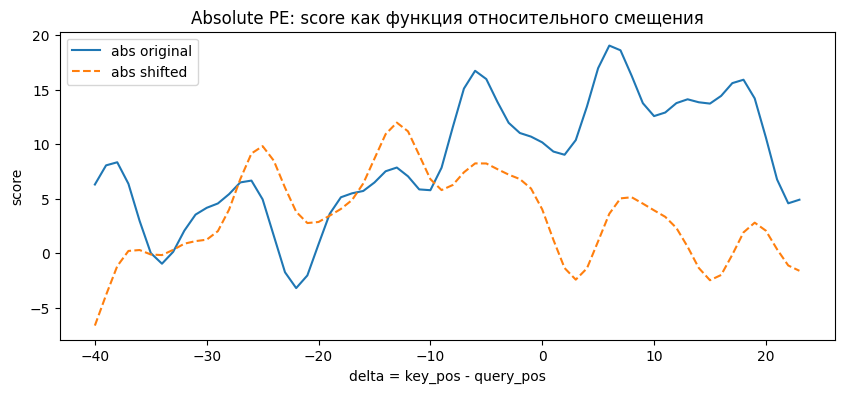

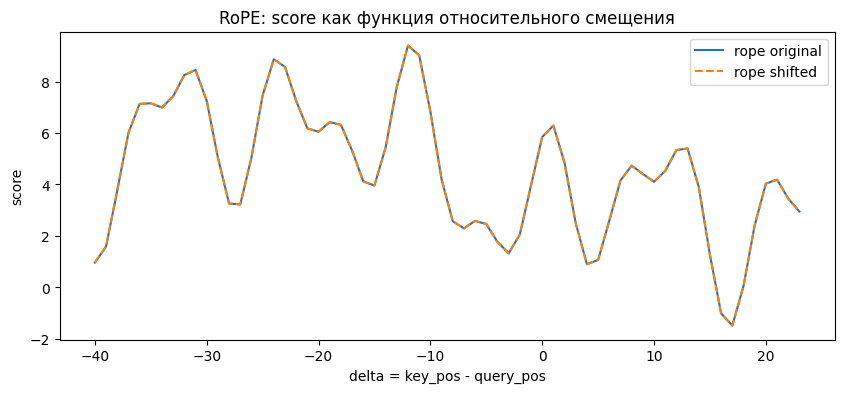

Среднее изменение после глобального сдвига:
  absolute PE: 6.860773
  RoPE:        0.000000


In [12]:
rng = np.random.default_rng(7)

T = 64
d = 32
shift = 20

x = rng.normal(size=(d,))
X = np.tile(x[None, :], (T, 1))

Wq = rng.normal(scale=0.5, size=(d, d))
Wk = rng.normal(scale=0.5, size=(d, d))

m = 40  # позиция запроса в "локальных" координатах

# ---- Absolute PE ----
P1 = build_sinusoidal_table(T, d)
P2 = build_sinusoidal_table(T + shift, d)[shift:shift+T]

X_abs_1 = X + P1
X_abs_2 = X + P2

Q_abs_1 = X_abs_1 @ Wq
K_abs_1 = X_abs_1 @ Wk
Q_abs_2 = X_abs_2 @ Wq
K_abs_2 = X_abs_2 @ Wk

scores_abs_1 = attention_scores(Q_abs_1[m], K_abs_1)
scores_abs_2 = attention_scores(Q_abs_2[m], K_abs_2)

# ---- RoPE ----
Q0 = X @ Wq
K0 = X @ Wk

pos1 = np.arange(T)
pos2 = np.arange(shift, shift + T)

Q_rope_1 = apply_rope_batch(Q0, pos1)
K_rope_1 = apply_rope_batch(K0, pos1)
Q_rope_2 = apply_rope_batch(Q0, pos2)
K_rope_2 = apply_rope_batch(K0, pos2)

scores_rope_1 = attention_scores(Q_rope_1[m], K_rope_1)
scores_rope_2 = attention_scores(Q_rope_2[m], K_rope_2)

# Сравним по относительному расстоянию delta = n - m
delta = np.arange(T) - m

plt.figure(figsize=(10, 4))
plt.plot(delta, scores_abs_1, label="abs original")
plt.plot(delta, scores_abs_2, "--", label="abs shifted")
plt.title("Absolute PE: score как функция относительного смещения")
plt.xlabel("delta = key_pos - query_pos")
plt.ylabel("score")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(delta, scores_rope_1, label="rope original")
plt.plot(delta, scores_rope_2, "--", label="rope shifted")
plt.title("RoPE: score как функция относительного смещения")
plt.xlabel("delta = key_pos - query_pos")
plt.ylabel("score")
plt.legend()
plt.show()

abs_diff = np.mean(np.abs(scores_abs_1 - scores_abs_2))
rope_diff = np.mean(np.abs(scores_rope_1 - scores_rope_2))

print(f"Среднее изменение после глобального сдвига:")
print(f"  absolute PE: {abs_diff:.6f}")
print(f"  RoPE:        {rope_diff:.6f}")

## Зачем вообще нужен KV-cache?

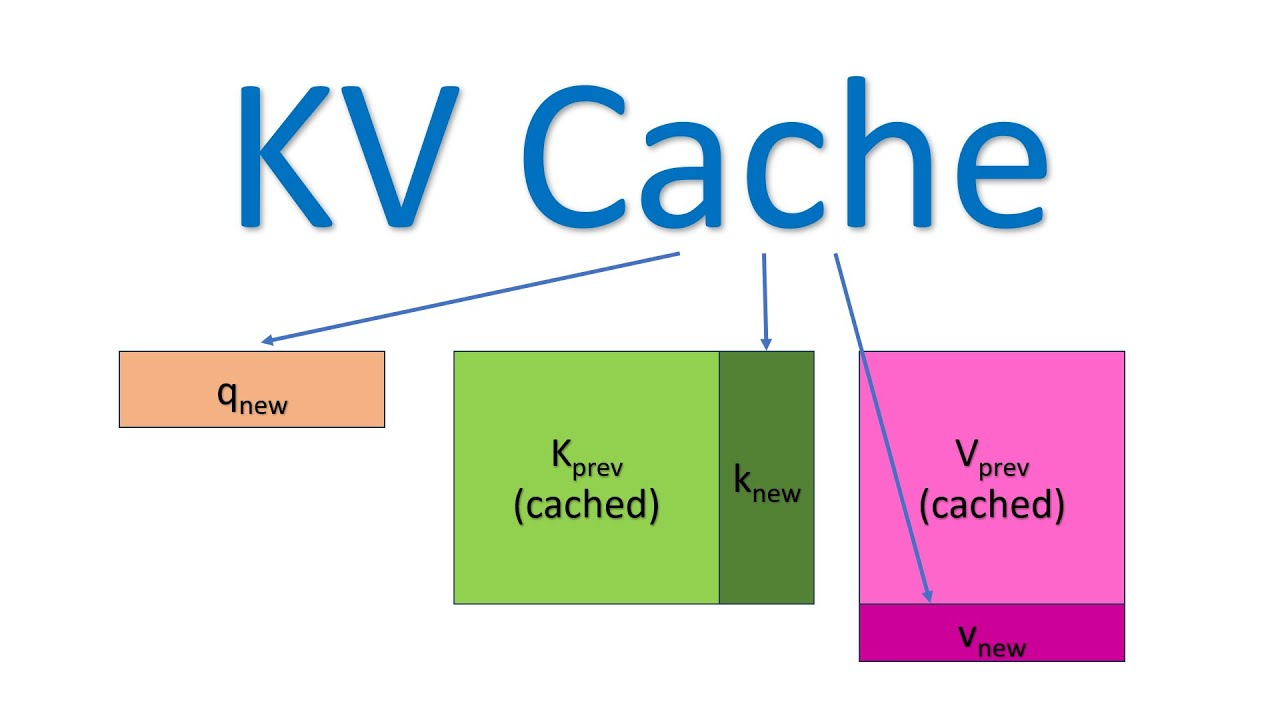


### Что происходит при autoregressive decoding

Когда модель генерирует следующий токен, она каждый раз делает что-то вроде:

- есть префикс длины `t`;
- считаем attention для нового токена ко всем предыдущим `t` токенам;
- получаем следующий токен;
- повторяем.

### Наивный вариант без KV-cache

На каждом шаге заново пересчитываются:
- все старые `K`
- все старые `V`

Это очень невыгодно, потому что прошлые токены **не изменились**.

### Идея KV-cache

Сохранить уже посчитанные `K` и `V` для предыдущих токенов.  
Тогда на новом шаге считаем только:
- новый `q_t`
- новый `k_t`
- новый `v_t`

а старые ключи и значения просто читаем из cache.

## Single-head attention для decoding


In [13]:
def causal_self_attention_last_token(X, Wq, Wk, Wv):
    '''
    X: [t, d]
    Возвращает output только для последнего токена.
    Наивный вариант: заново считает Q,K,V для всей последовательности.
    '''
    Q = X @ Wq
    K = X @ Wk
    V = X @ Wv
    q = Q[-1]                            # [d]
    scores = (K @ q) / math.sqrt(K.shape[1])   # [t]
    probs = softmax(scores, axis=0)      # [t]
    out = probs @ V                      # [d]
    return out

def cached_attention_step(x_t, K_cache, V_cache, Wq, Wk, Wv):
    '''
    x_t: [d] - новый токен
    K_cache, V_cache: уже накопленные ключи и значения
    '''
    q_t = x_t @ Wq
    k_t = x_t @ Wk
    v_t = x_t @ Wv

    if K_cache is None:
        K_all = k_t[None, :]
        V_all = v_t[None, :]
    else:
        K_all = np.vstack([K_cache, k_t[None, :]])
        V_all = np.vstack([V_cache, v_t[None, :]])

    scores = (K_all @ q_t) / math.sqrt(K_all.shape[1])
    probs = softmax(scores, axis=0)
    out = probs @ V_all
    return out, K_all, V_all

## Проверка корректности: cache и naive должны давать один и тот же результат

KV-cache — это не другой способ декодирования, а **другая организация вычислений**.

In [15]:
rng = np.random.default_rng(0)

T = 20
d = 32

X = rng.normal(size=(T, d))
Wq = rng.normal(scale=0.4, size=(d, d))
Wk = rng.normal(scale=0.4, size=(d, d))
Wv = rng.normal(scale=0.4, size=(d, d))

# Наивный способ: на каждом шаге заново считаем всё по префиксу
outs_naive = []
for t in range(1, T + 1):
    out_t = causal_self_attention_last_token(X[:t], Wq, Wk, Wv)
    outs_naive.append(out_t)
outs_naive = np.stack(outs_naive)

# Cached-способ
outs_cached = []
K_cache = None
V_cache = None
for t in range(T):
    out_t, K_cache, V_cache = cached_attention_step(X[t], K_cache, V_cache, Wq, Wk, Wv)
    outs_cached.append(out_t)
outs_cached = np.stack(outs_cached)

max_err = np.max(np.abs(outs_naive - outs_cached))
print("Максимальная абсолютная ошибка между naive и cached:", max_err)

Максимальная абсолютная ошибка между naive и cached: 4.218847493575595e-15


## Benchmark: decoding без KV-cache vs с KV-cache

- без cache — много лишних пересчётов;
- с cache — старые `K,V` используются повторно.

In [16]:
def benchmark_decoding(T=400, d=64, seed=0):
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(T, d))
    Wq = rng.normal(scale=0.3, size=(d, d))
    Wk = rng.normal(scale=0.3, size=(d, d))
    Wv = rng.normal(scale=0.3, size=(d, d))

    # naive
    t0 = time.perf_counter()
    for t in range(1, T + 1):
        _ = causal_self_attention_last_token(X[:t], Wq, Wk, Wv)
    t1 = time.perf_counter()

    # cached
    K_cache = None
    V_cache = None
    t2 = time.perf_counter()
    for t in range(T):
        _, K_cache, V_cache = cached_attention_step(X[t], K_cache, V_cache, Wq, Wk, Wv)
    t3 = time.perf_counter()

    return (t1 - t0), (t3 - t2)

lengths = [100, 200, 400, 800]
times_naive = []
times_cached = []

for T in lengths:
    naive_t, cached_t = benchmark_decoding(T=T, d=64, seed=123)
    times_naive.append(naive_t)
    times_cached.append(cached_t)
    print(f"T={T:4d} | naive={naive_t:.4f}s | cached={cached_t:.4f}s | speedup={naive_t/cached_t:.2f}x")

T= 100 | naive=0.0096s | cached=0.0034s | speedup=2.78x
T= 200 | naive=0.0261s | cached=0.0112s | speedup=2.32x
T= 400 | naive=0.1003s | cached=0.0289s | speedup=3.47x
T= 800 | naive=0.4068s | cached=0.0840s | speedup=4.84x


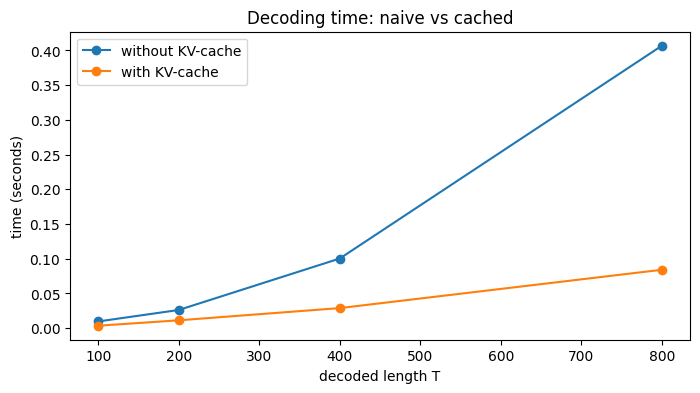

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(lengths, times_naive, marker="o", label="without KV-cache")
plt.plot(lengths, times_cached, marker="o", label="with KV-cache")
plt.xlabel("decoded length T")
plt.ylabel("time (seconds)")
plt.title("Decoding time: naive vs cached")
plt.legend()
plt.show()

По мере роста длины:
- **naive** начинает проигрывать всё сильнее;
- **cached** остаётся заметно быстрее.

Это и есть главный смысл KV-cache:
> не пересчитывать старые ключи и значения заново на каждом шаге генерации.

## А какая цена у KV-cache? Память

KV-cache экономит время, но тратит память.

Грубая оценка памяти для одного слоя:

$
\text{memory} \approx 2 \times B \times T \times n_{kv} \times d_{head} \times \text{bytes_per_element}
$

где:
- `2` — потому что храним и `K`, и `V`;
- `B` — batch size;
- `T` — длина контекста;
- `n_kv` — число KV-heads;
- `d_head` — размер головы.

Это очень полезная формула для обсуждения **MHA vs GQA**.

In [18]:
def kv_cache_size_mb(batch_size, seq_len, n_kv_heads, d_head, bytes_per_elem=2, n_layers=1):
    total_bytes = 2 * batch_size * seq_len * n_kv_heads * d_head * bytes_per_elem * n_layers
    return total_bytes / (1024 ** 2)

batch_size = 1
d_head = 128
n_layers = 32

seq_lens = [2048, 8192, 32768]
configs = [
    ("MHA-like: 32 KV heads", 32),
    ("GQA-like: 8 KV heads", 8),
    ("MQA-like: 1 KV head", 1),
]

for seq_len in seq_lens:
    print(f"Context length = {seq_len}")
    for name, n_kv in configs:
        mb = kv_cache_size_mb(batch_size, seq_len, n_kv, d_head, bytes_per_elem=2, n_layers=n_layers)
        print(f"  {name:24s} -> {mb:10.1f} MB")
    print()

Context length = 2048
  MHA-like: 32 KV heads    ->     1024.0 MB
  GQA-like: 8 KV heads     ->      256.0 MB
  MQA-like: 1 KV head      ->       32.0 MB

Context length = 8192
  MHA-like: 32 KV heads    ->     4096.0 MB
  GQA-like: 8 KV heads     ->     1024.0 MB
  MQA-like: 1 KV head      ->      128.0 MB

Context length = 32768
  MHA-like: 32 KV heads    ->    16384.0 MB
  GQA-like: 8 KV heads     ->     4096.0 MB
  MQA-like: 1 KV head      ->      512.0 MB

